In [1]:
import anndata as ad
import numpy as np
import torch
import pandas as pd

from geome import ann2data, iterables, transforms
import squidpy as sq

In [2]:
coordinates = np.random.rand(50, 2)
# make sure that there are two clusters of spatial coordinates
# so that the resulting splits number of edges will be the same
# as the sum of the number of edges in each cluster
func_args = {"radius": 4.0, "coord_type": "generic", "library_key": "image_id"}
coordinates[:25, 0] += 100
adata_gt = ad.AnnData(
    np.random.rand(50, 2),
    obs={"cell_type": ["b"] * 20 + ["a"] * 20 + ["c"] * 5 + ["d"] * 5, "image_id": list("xy" * 20) + ["z"] * 10},
    obsm={"spatial_init": coordinates},
)
adata_gt.obs["image_id"] = pd.Categorical(adata_gt.obs["image_id"])
sq.gr.spatial_neighbors(adata_gt, spatial_key="spatial_init", library_key="image_id")

In [3]:
prediction_obs = "cell_type"
subset_dict = {}
adj_matrix_loc = "spatial"
category_to_iterate = "image_id"

In [4]:
adata_gt

AnnData object with n_obs × n_vars = 50 × 2
    obs: 'cell_type', 'image_id'
    uns: 'spatial_neighbors'
    obsm: 'spatial_init'
    obsp: 'spatial_connectivities', 'spatial_distances'

In [5]:
fields = {
    "x": ["X"],
    "y": [f"obs/{prediction_obs}"],
    "obs_names": ["obs_names"],
}

preprocess = transforms.Compose(
    [
        transforms.Subset(key_value=subset_dict, axis="obs"),
        transforms.Categorize(keys=list(subset_dict.keys()) + [prediction_obs], axis="obs"),
        transforms.SaveOneHotEncodeLabels(keys=[prediction_obs], axis="obs", key_added=prediction_obs),
    ]
)

transform = transforms.Compose(
    [
        transforms.AddEdgeIndex(
            edge_index_key="edge_index", spatial_key="spatial_init", func_args={}, key_added=adj_matrix_loc
        ),
    ]
)

adata_gt.obs_names_make_unique()

a2d = ann2data.Ann2DataBasic(
    fields=fields,
    adata2iter=iterables.ToCategoryIterator(category_to_iterate, axis="obs", preserve_categories=[prediction_obs]),
    preprocess=preprocess,
    transform=transform,
    save_preprocessed_adata=True,
)

datas = a2d(adata_gt)

call new
{'cell_type': ['a', 'b', 'c', 'd']}


/home/icb/francesca.drummer/1-Projects/geome/src/geome/transforms/categorize.py:38: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  getattr(adata, self.axis)[key] = getattr(adata, self.axis)[key].astype("category")


In [10]:
pyg, adata = list(datas)
print(pyg[:3], adata)

[Data(x=[20, 2], y=[20, 4], obs_names=[20]), Data(x=[20, 2], y=[20, 4], obs_names=[20]), Data(x=[10, 2], y=[10, 4], obs_names=[10])] AnnData object with n_obs × n_vars = 50 × 2
    obs: 'cell_type', 'image_id'
    uns: 'spatial_neighbors', 'cell_type_mappings'
    obsm: 'spatial_init', 'cell_type'
    obsp: 'spatial_connectivities', 'spatial_distances'


In [7]:
obj = adata_gt.obs["cell_type"]

Issue: Different number of categories in adata edges

In [2]:
coordinates = np.random.rand(50, 2)
# make sure that there are two clusters of spatial coordinates
# so that the resulting splits number of edges will be the same
# as the sum of the number of edges in each cluster
func_args = {"radius": 4.0, "coord_type": "generic", "library_key": "image_id"}
# func_args = {"radius": 4.0, "coord_type": "generic"}
coordinates[:25, 0] += 100
adata_gt = ad.AnnData(
    np.random.rand(50, 2),
    # obs={"cell_type": ["a"] * 20 + ["b"] * 20 + ["c"] * 5 + ["d"] * 5, "image_id": list("xy" * 20) + ["z"] * 10},
    obs={"cell_type": ["a"] * 20 + ["b"] * 20 + ["c"] * 5 + ["d"] * 5, "image_id": list("xy" * 25)},
    obsm={"spatial_init": coordinates},
)
adata_gt.obs["image_id"] = pd.Categorical(adata_gt.obs["image_id"])

In [3]:
adata_gt.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24',
       '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36',
       '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48',
       '49'],
      dtype='object')

In [4]:
a2d = ann2data.Ann2DataBasic(
    fields={
        "x": ["X"],
        "edge_index": ["uns/edge_index"],
        "edge_weight": ["uns/edge_weight"],
        "y": ["obs/cell_type"],
        "obs_names": ["obs_names"],
    },
    adata2iter=iterables.ToCategoryIterator("image_id", axis="obs", preserve_categories=["cell_type"]),
    preprocess=transforms.Categorize(keys=["cell_type", "image_id"]),
    transform=transforms.AddEdgeIndex(
        spatial_key="spatial_init",
        key_added="graph",
        edge_index_key="edge_index",
        edge_weight_key="edge_weight",
        func_args=func_args,
    ),
)

In [153]:
a2d = ann2data.Ann2DataByCategory(
    fields={
        "x": ["X"],
        "edge_index": ["uns/edge_index"],
        "edge_weight": ["uns/edge_weight"],
        "y": ["obs/cell_type"],
    },
    category="cell_type",
    preprocess=transforms.Categorize(keys=["cell_type", "image_id"]),
    transform=transforms.AddEdgeIndex(
        spatial_key="spatial_init",
        key_added="graph",
        edge_index_key="edge_index",
        edge_weight_key="edge_weight",
        func_args=func_args,
    ),
)

In [157]:
datas = list(a2d(adata_gt.copy()))
assert len(datas) == 4

In [124]:
big_adata_tf = transforms.Compose(
    [
        transforms.Categorize(keys=["cell_type", "image_id"]),
        transforms.AddEdgeIndex(
            spatial_key="spatial_init",
            key_added="graph",
            edge_index_key="edge_index",
            edge_weight_key="edge_weight",
            func_args=func_args,
        ),
    ]
)
big_adata = big_adata_tf(adata_gt.copy())

In [94]:
for d in datas:
    print(d)
    print(d.y)

Data(x=[20, 2], edge_index=[2, 198], y=[20, 4], edge_weight=[198])
tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.]])
Data(x=[20, 2], edge_index=[2, 188], y=[20, 4], edge_weight=[188])
tensor([[1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
        [0., 1., 0., 0.],
       

In [29]:
# check if the concatenation of the two datasets is the same as the big dataset
assert torch.allclose(torch.cat([d.x for d in datas]), torch.from_numpy(big_adata.X).to(torch.float))
assert sum([d.edge_index.shape[1] for d in datas]) == big_adata.uns["edge_index"].shape[1]
adatas = list(iterables.ToCategoryIterator(category="cell_type")(big_adata))
assert np.allclose(
    np.array(adatas[0].obsp["graph_distances"].todense()),
    np.array(big_adata.obsp["graph_distances"][0:25, 0:25].todense()),
)
assert np.allclose(
    np.array(adatas[1].obsp["graph_distances"].todense()),
    np.array(big_adata.obsp["graph_distances"][25:, 25:].todense()),
)

AssertionError: 

## Visualization

In [132]:
# Set random seed for reproducibility
np.random.seed(42)

# Define cluster centers
cluster_centers = np.array(
    [
        [1, 1],  # Center for the first 20 points
        [5, 5],  # Center for the next 20 points
        [1, 5],  # Center for the last 10 points
    ]
)

points_cluster_1 = cluster_centers[0] + np.random.randn(20, 2)
points_cluster_2 = cluster_centers[1] + np.random.randn(20, 2)
points_cluster_3 = cluster_centers[2] + np.random.randn(10, 2)

# Combine all points into a single array
coordinates = np.vstack((points_cluster_1, points_cluster_2, points_cluster_3))

adata_gt = ad.AnnData(
    np.random.rand(50, 2),
    obs={"cell_type": list("ab" * 20) + ["c"] * 5 + ["d"] * 5, "image_id": ["x"] * 20 + ["y"] * 20 + ["z"] * 10},
    obsm={"spatial_init": coordinates},
)

adata_gt.obs["image_id"] = pd.Categorical(adata_gt.obs["image_id"])

AnnData object with n_obs × n_vars = 50 × 2
    obs: 'cell_type', 'image_id'
    uns: 'spatial_neighbors'
    obsm: 'spatial_init'
    obsp: 'spatial_connectivities', 'spatial_distances'


/home/icb/francesca.drummer/tools/apps/mamba/envs/geome/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/home/icb/francesca.drummer/tools/apps/mamba/envs/geome/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


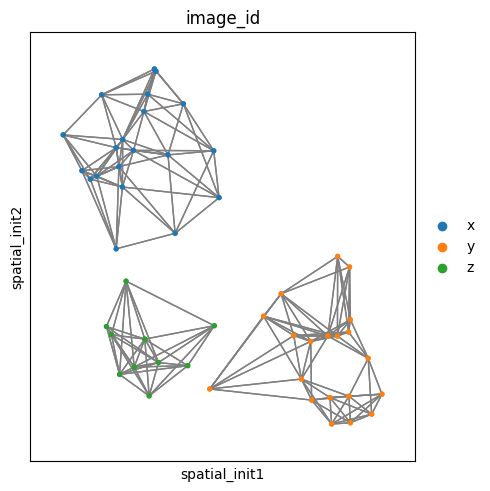

In [87]:
sq.gr.spatial_neighbors(adata_gt, spatial_key="spatial_init", library_key="image_id")
print(adata_gt)
sq.pl.spatial_scatter(
    adata_gt,
    spatial_key="spatial_init",
    shape=None,
    color="image_id",
    size=30,
    connectivity_key="spatial_connectivities",
)

AnnData object with n_obs × n_vars = 50 × 2
    obs: 'cell_type', 'image_id'
    uns: 'spatial_neighbors', 'image_id_colors'
    obsm: 'spatial_init'
    obsp: 'spatial_connectivities', 'spatial_distances'


/home/icb/francesca.drummer/tools/apps/mamba/envs/geome/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/home/icb/francesca.drummer/tools/apps/mamba/envs/geome/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


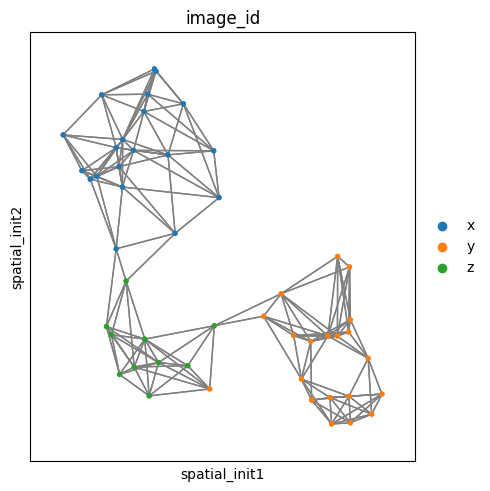

In [88]:
sq.gr.spatial_neighbors(adata_gt, spatial_key="spatial_init")
print(adata_gt)
sq.pl.spatial_scatter(
    adata_gt,
    spatial_key="spatial_init",
    shape=None,
    color="image_id",
    size=30,
    connectivity_key="spatial_connectivities",
)